### IMport Dependencies

In [11]:
import openai
import pandas as pd
from qdrant_client import QdrantClient, models
from qdrant_client.models import VectorParams, Distance, SparseVectorParams, Modifier,PayloadSchemaType, PointStruct, Document, Prefetch, FusionQuery

from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send
from langgraph.prebuilt import ToolNode
from IPython.display import Image, display
from typing import Literal, Annotated, List, Any
from operator import add
import random
from jinja2 import Template
from langchain_core.messages import SystemMessage, HumanMessage
import instructor
from langsmith import traceable, get_current_run_tree
from openai import OpenAI
import os


In [3]:
client=OpenAI()
QDRANT_URL = os.getenv("QDRANT_URL", "http://localhost:6333")

In [4]:
qudrant_client=QdrantClient(url="http://localhost:6333/")

In [5]:
def get_embedding(text,model="text-embedding-3-small"):
    response=openai.embeddings.create(
        input=[text],
        model=model
    )
    return response.data[0].embedding

In [13]:
def reteriver_data(query, quadrant_client, k):
    query_embedding = get_embedding(query)

    result = quadrant_client.query_points(
        collection_name="Amazon-items-collection-02-hybrid-serach",
        prefetch=[
            Prefetch(
                query=query_embedding,
                using="text-embedding-model-3-small",
                limit=20
            ),
            Prefetch(
                query=Document(
                    text=query,
                    model="qdrant/bm25"
                ),
                using="bm25",
                limit=20
            )

        ],
        query=FusionQuery(fusion="rrf"),
        limit=k
    )

    retrieved_context_ids = []
    retrieved_context = []
    similarity_scores = []
    retrieved_context_rating = []
    retrieved_image_urls = []
    retrieved_prices = []

    for point in result.points:
        payload = point.payload or {}
        retrieved_context_ids.append(payload.get("parent_asin"))
        retrieved_context.append(payload.get("description", ""))
        retrieved_context_rating.append(payload.get("average_rating"))
        similarity_scores.append(point.score)
        retrieved_image_urls.append(payload.get("image", ""))
        retrieved_prices.append(payload.get("price"))

    return (
        retrieved_context,
        retrieved_context_ids,
        retrieved_context_rating,
        similarity_scores,
        retrieved_image_urls,
        retrieved_prices
    )


In [7]:
query="Can i get tablet for my kids , a watch for me and a labtop for my wife"

In [14]:
class QueryExpandResponse(BaseModel):
    expanded_query: List[str] = Field(description="A list of statements that are related to the original query")

def query_espansion_node(query: str) -> dict:
    prompt_template = """
    You are a query expansion module in a shopping assistant. Your job is to rewrite the customer's query into distinct statements for semantic search.
    ## Instructions:
    - Expand the customer's query into a list of distinct statements (1 to 5 concise statements)
    - Each statement should capture a separate product or attribute from the query
    - Use natural product description language
    - Do not produce multiple statements that express the same intent

    ## Examples:
    Query: "Can I get a tablet for my kid, a watch for me and a laptop for my wife?"
    Statements:
    - tablet for kids
    - watch for adults
    - laptop

    Query: "I need a warm winter jacket for hiking"
    Statements:
    - warm winter jacket
    - hiking outfit for cold weather

    <query>:
    {{query}}
    </query>
    """
    template = Template(prompt_template)
    prompt = template.render(query=query)
    
    client = instructor.from_provider(
        "openai/gpt-5.4-nano",
        mode=instructor.Mode.RESPONSES_TOOLS
    )
    response, raw_response = client.create_with_completion(
        messages = [
            {"role":"system", "content":prompt},
        ],
        response_model=QueryExpandResponse,
        reasoning={"effort":"none"}
    )
    return {
        'queries': response.statements
    }

In [12]:
result=query_espansion_node("Can i get tablet for my kids , a watch for me and a labtop for my wife")

AttributeError: 'QueryExpandResponse' object has no attribute 'statements'

In [ ]:
result

{'queries': ['tablet for kids', 'watch for adults', 'laptop for wife']}

LangGraph


QueryExpansion Node

In [15]:
class State(BaseModel):
    expanded_query: List[str] = []
    reterived_context: Annotated[List[str], add] = []
    initial_query: str = ""
    answer: str = ""


##Query Expansion Node

In [26]:
class QueryExpandResponse(BaseModel):
    statements: List[str] = Field(description="A list of statements that are related to the original query")

In [17]:
@traceable(
    name="query_expansion",
    run_type="llm"
)
def query_expansion_node(state:State) -> dict:
    prompt_template = """
    You are a query expansion module in a shopping assistant. Your job is to rewrite the customer's query into distinct statements for semantic search.
    ## Instructions:
    - Expand the customer's query into a list of distinct statements (1 to 5 concise statements)
    - Each statement should capture a separate product or attribute from the query
    - Use natural product description language
    - Do not produce multiple statements that express the same intent

    ## Examples:
    Query: "Can I get a tablet for my kid, a watch for me and a laptop for my wife?"
    Statements:
    - tablet for kids
    - watch for adults
    - laptop

    Query: "I need a warm winter jacket for hiking"
    Statements:
    - warm winter jacket
    - hiking outfit for cold weather

    <query>:
    {{query}}
    </query>
    """
    template = Template(prompt_template)
    prompt = template.render(query=state.initial_query)
    
    client = instructor.from_provider(
        "openai/gpt-5.4-nano",
        mode=instructor.Mode.RESPONSES_TOOLS
    )
    response, raw_response = client.create_with_completion(
        messages = [
            {"role":"system", "content":prompt},
        ],
        response_model=QueryExpandResponse,
        reasoning={"effort":"none"}
    )
    return {
        'expanded_query': response.statements
    }


Reteriver Node

In [18]:
def get_embedding(text,model="text-embedding-3-small"):
    response=openai.embeddings.create(
        input=[text],
        model=model
    )
    return response.data[0].embedding
    
def reteriver_data(query, quadrant_client, k):
    query_embedding = get_embedding(query)

    result = quadrant_client.query_points(
        collection_name="Amazon-items-collection-02-hybrid-serach",
        prefetch=[
            Prefetch(
                query=query_embedding,
                using="text-embedding-model-3-small",
                limit=20
            ),
            Prefetch(
                query=Document(
                    text=query,
                    model="qdrant/bm25"
                ),
                using="bm25",
                limit=20
            )

        ],
        query=FusionQuery(fusion="rrf"),
        limit=k
    )

    retrieved_context_ids = []
    retrieved_context = []
    similarity_scores = []
    retrieved_context_rating = []
    retrieved_image_urls = []
    retrieved_prices = []

    for point in result.points:
        payload = point.payload or {}
        retrieved_context_ids.append(payload.get("parent_asin"))
        retrieved_context.append(payload.get("description", ""))
        retrieved_context_rating.append(payload.get("average_rating"))
        similarity_scores.append(point.score)
        retrieved_image_urls.append(payload.get("image", ""))
        retrieved_prices.append(payload.get("price"))

    return (
        retrieved_context,
        retrieved_context_ids,
        retrieved_context_rating,
        similarity_scores,
        retrieved_image_urls,
        retrieved_prices
    )



def retriever_node(state:State) -> dict:
    retrieved_context = []

    for query in state.expanded_query:
        context, _, _, _, _, _ = reteriver_data(query, qudrant_client, k=5)
        retrieved_context.extend(context)  # extend with list of strings

    return {
        "reterived_context": retrieved_context
    }


#### Aggregator Node

In [28]:
class AggregatorResponse(BaseModel):
    answer: str

In [19]:
class AggregratorNode(BaseModel):
    answer:str=Field(description="Answer to the question")


In [20]:
@traceable(
    name="generate_answer",
    run_type="llm",
    metadata={
        "ls_provider": "openai",
        "ls_model": "gpt-5.4-mini"
    }
)

def aggregator_node(state: State) -> dict:
    preprocessed_context = '\n'.join(state.reterived_context)

    prompt_template = """
    You are a shopping assistant that can answer questions about the products in stock.
      
    You will be given a question and a list of context.

    Instructions:
    - Answer the question based on the context only.
    - Never use word context and refer to it as the available products.
    - The answer to the question should contain  detailed information about the product and returned with detailed specification in bullet points.

    Context:
    {{preprocessed_context}}

    Question:
    {{question}}
    """
    template = Template(prompt_template)
    prompt = template.render(preprocessed_context=preprocessed_context, question=state.initial_query)
    
    client = instructor.from_provider(
        "openai/gpt-5.4-mini",
        mode=instructor.Mode.RESPONSES_TOOLS
    )
    response, raw_response = client.create_with_completion(
        messages = [
            {"role":"system", "content":prompt},
        ],
        response_model=AggregatorResponse,
        reasoning={"effort":"none"}
    )
    return {
        'answer': response.answer
    }

In [21]:
workflow = StateGraph(State)

workflow.add_node("query_expansion_node", query_expansion_node)
workflow.add_node('retriever_node', retriever_node)
workflow.add_node('aggregator_node', aggregator_node)

workflow.add_edge(START, "query_expansion_node")
workflow.add_edge("query_expansion_node", "retriever_node")
workflow.add_edge("retriever_node", "aggregator_node")
workflow.add_edge("aggregator_node", END)

graph = workflow.compile()

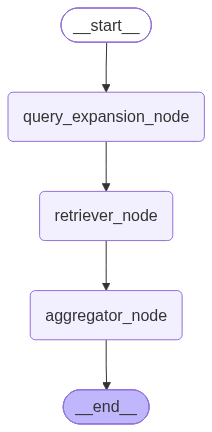

In [22]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [34]:
query = "Can I get a laptop for me and a watch for my wife and some tablets for my kids"

In [35]:
initial_state = {
    "initial_query": query
}

In [36]:
result = graph.invoke(initial_state)

In [37]:
result

{'expanded_query': ['laptop for personal use',
  'watch for a wife',
  'tablets for kids'],
 'reterived_context': ['jumper Laptop 14 inch 12GB DDR4 RAM 256GB SSD,Intel Quad Core Celeron N4100, Windows 11 Thin and Light Laptops Computer, Full HD 1080P Display,HD Webcam,Dual Speakers,2.4/5Ghz WiFi,Long Battery Life【Power Laptop】Pre-loaded with Windows 11 home offering enhanced productivity, security and privacy features.Powered by an Intel Celeron quad core processor N4100,(4MB Cache, Main frequency 1.1GHz,up to 2.4GHz) Built-in Intel UHD Graphics 600, Support 4K Video@60Hz.【Memory & Storage】12GB LPDDR4 high-bandwidth memory for smoothly running multiple applications and browser tabs simultaneously. 256GB solid-state drive for fast boot and data transfer, and 256GB TF card expansion support.【Thin and Light Body Laptop】 This thin and stylish laptop body is only 18mm thin and 1.2kg light, it has a 14 inch 1920×1080 Full HD resolution and 82% screen to body ratio maximizes viewing are.【Conn